# Modelado de Series

## ETL

In [ ]:
# 1. Imports y configuración --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')  # estilo profesional de gráficos

In [ ]:
# Función para métricas de validación
def compute_metrics(actual, forecast):
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae  = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    return rmse, mae, mape

In [ ]:
# 2. Carga de datos ----------------------------------------------------
try:
    import polars as pl
    df_pl = (
        pl.read_csv('ecommerce_sales_dataset.csv')
          .with_columns(pl.col('order_date').str.strptime(pl.Date, '%Y-%m-%d'))
          .sort('order_date')
    )
    df = df_pl.to_pandas().set_index('order_date')
    print("Datos cargados con Polars")
except ImportError:
    df = pd.read_csv('ecommerce_sales_dataset.csv', parse_dates=['order_date'])
    df.set_index('order_date', inplace=True)
    print("Polars no disponible, cargado con pandas")

Datos cargados con Polars


In [ ]:
# 3. División train/test ------------------------------------------------------
train = df[:'2023-12-31'].copy()
test  = df['2024-01-01':].copy()

In [ ]:
# 4. Transformación logarítmica -----------------------------------------------
# Aplicar log a total_sales para estabilizar varianza
train['log_total_sales'] = np.log(train['total_sales'])
test ['log_total_sales'] = np.log(test ['total_sales'])

In [ ]:
# 5. Resampling ---------------------------------------------------------------
# Semanal y mensual de total_sales y website_visits
train_weekly  = train[['total_sales','website_visits']].resample('W').sum()
train_monthly = train[['total_sales','website_visits']].resample('M').sum()

/tmp/ipython-input-10-780679954.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  train_monthly = train[['total_sales','website_visits']].resample('M').sum()


In [ ]:
# 6. Suavizamientos -----------------------------------------------------------
# SES y DES sobre website_visits (serie diaria)
ses = SimpleExpSmoothing(train['website_visits']).fit()
des = ExponentialSmoothing(train['website_visits'], trend='add').fit()
train['SES_visits'] = ses.fittedvalues
train['DES_visits'] = des.fittedvalues

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
# 7. Diferenciaciones --------------------------------------------------------
# 7.1 Diferenciaciones clásicas
train['diff1_sales']   = train['total_sales'].diff()
train['diff7_sales']   = train['total_sales'].diff(7)
train['diff365_sales'] = train['total_sales'].diff(365)

In [ ]:
# 7.2 Conocimiento complementario: otras formas de detrending/desestacionalizar
#    - STL decomposition (Seasonal-Trend-Loess)
stl = STL(train['total_sales'], period=365)
res = stl.fit()
train['stl_trend']     = res.trend
train['stl_seasonal']  = res.seasonal
train['stl_resid']     = res.resid
#    - HP filter (Hodrick-Prescott) para extraer tendencia
from statsmodels.tsa.filters.hp_filter import hpfilter
cycle, trend_hp = hpfilter(train['total_sales'], lamb=1600)
train['hp_trend']      = trend_hp
train['hp_cycle']      = cycle

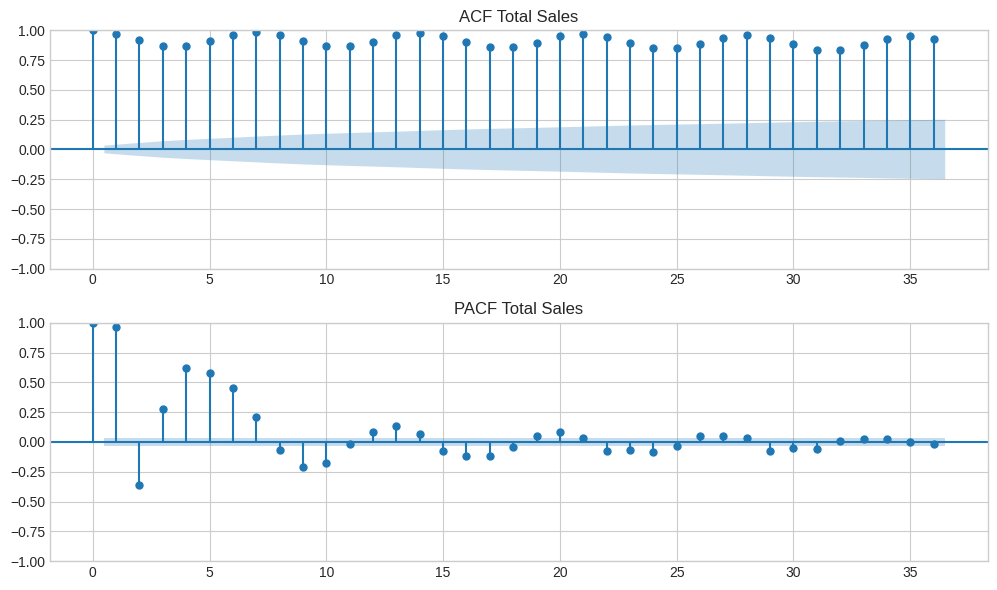

In [ ]:
# 8. Exploración estadística: ACF y PACF -------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(train['total_sales'].dropna(), ax=ax1, title='ACF Total Sales')
plot_pacf(train['total_sales'].dropna(), ax=ax2, title='PACF Total Sales')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


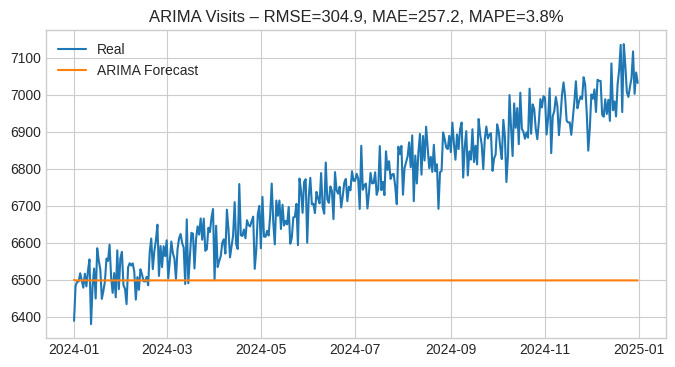

In [ ]:
# 9. Modelado ARIMA(1,1,1) sobre website_visits --------------------------------
model_arima = ARIMA(train['website_visits'], order=(1,1,1)).fit()
pred_arima  = model_arima.forecast(steps=len(test))
rmse_a, mae_a, mape_a = compute_metrics(test['website_visits'], pred_arima)
plt.figure(figsize=(8,4))
plt.plot(test.index, test['website_visits'], label='Real')
plt.plot(test.index, pred_arima, label='ARIMA Forecast')
plt.title(f'ARIMA Visits – RMSE={rmse_a:.1f}, MAE={mae_a:.1f}, MAPE={mape_a:.1f}%')
plt.legend(); plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


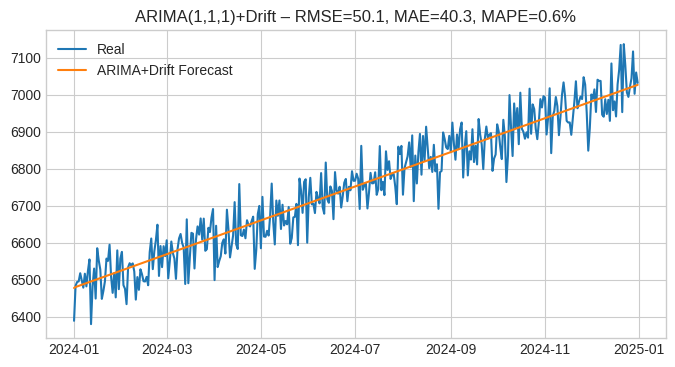

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# entreno el ARIMA pero con drift ("trend='t'")
model_arima_drift = ARIMA(
    train['website_visits'],
    order=(1,1,1),
    trend='t'           # aquí agregamos una constante (drift)
).fit()

# pronóstico
pred_drift = model_arima_drift.forecast(steps=len(test))

# métricas
rmse_d, mae_d, mape_d = compute_metrics(test['website_visits'], pred_drift)

# gráfico
plt.figure(figsize=(8,4))
plt.plot(test.index, test['website_visits'], label='Real')
plt.plot(test.index, pred_drift,   label='ARIMA+Drift Forecast')
plt.title(f'ARIMA(1,1,1)+Drift – RMSE={rmse_d:.1f}, MAE={mae_d:.1f}, MAPE={mape_d:.1f}%')
plt.legend(); plt.show()

In [ ]:
# # 10. Modelado SARIMA(1,1,1)x(1,1,1,365) sobre total_sales --------------------
# model_sarima = ARIMA(
#     train['total_sales'],
#     order=(1,1,1),
#     seasonal_order=(1,1,1,365)
# ).fit()
# pred_sarima = model_sarima.forecast(steps=len(test))
# rmse_s, mae_s, mape_s = compute_metrics(test['total_sales'], pred_sarima)
# plt.figure(figsize=(8,4))
# plt.plot(test.index, test['total_sales'], label='Real')
# plt.plot(test.index, pred_sarima, label='SARIMA Forecast')
# plt.title(f'SARIMA Sales – RMSE={rmse_s:.1f}, MAE={mae_s:.1f}, MAPE={mape_s:.1f}%')
# plt.legend(); plt.show()

## El codigo demora mucho...
entonces podemos hacer un resampling

/tmp/ipython-input-18-517919144.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['total_sales'].resample('M').sum()


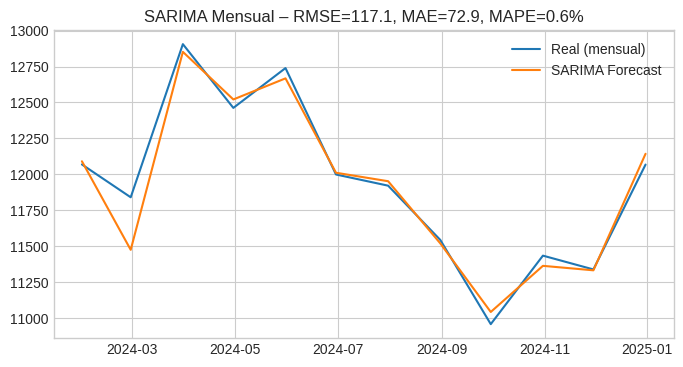

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Función de métricas
def compute_metrics(actual, forecast):
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae  = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    return rmse, mae, mape

# 1) Carga y resampling a mensual
df = pd.read_csv('ecommerce_sales_dataset.csv', parse_dates=['order_date'])
df.set_index('order_date', inplace=True)

# Agregamos totales mensuales
monthly = df['total_sales'].resample('M').sum()

# 2) División train/test (último año fuera)
train_m = monthly[:'2023-12-31']
test_m  = monthly['2024-01-01':]

# 3) Ajuste SARIMA(p,d,q)x(P,D,Q,12)
#    - Reduce drásticamente la cantidad de puntos (≈132 vs 4018)
model_m = ARIMA(
    train_m,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    trend='n'      # sin drift, por simplicidad
).fit()

# 4) Pronóstico mensual
pred_m = model_m.forecast(steps=len(test_m))

# 5) Métricas y gráfico
rmse_m, mae_m, mape_m = compute_metrics(test_m, pred_m)

plt.figure(figsize=(8,4))
plt.plot(test_m.index, test_m,    label='Real (mensual)')
plt.plot(test_m.index, pred_m,    label='SARIMA Forecast')
plt.title(f'SARIMA Mensual – RMSE={rmse_m:.1f}, MAE={mae_m:.1f}, MAPE={mape_m:.1f}%')
plt.legend(); plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


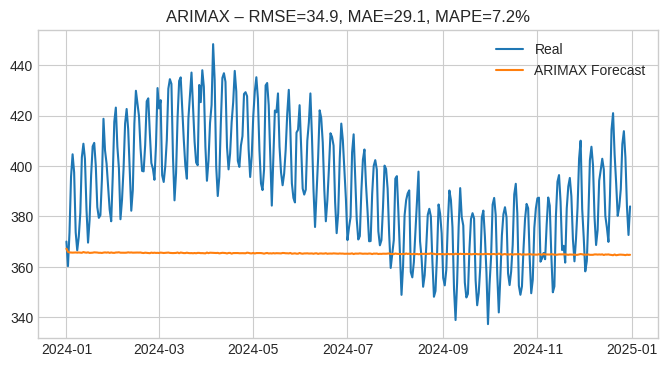

In [ ]:
# 11. Modelado ARIMAX(1,1,1) con exógena website_visits -----------------------
model_arimax = ARIMA(
    train['total_sales'],
    exog=train[['website_visits']],
    order=(1,1,1)
).fit()
pred_arimax = model_arimax.forecast(steps=len(test), exog=test[['website_visits']])
rmse_x, mae_x, mape_x = compute_metrics(test['total_sales'], pred_arimax)
plt.figure(figsize=(8,4))
plt.plot(test.index, test['total_sales'], label='Real')
plt.plot(test.index, pred_arimax, label='ARIMAX Forecast')
plt.title(f'ARIMAX – RMSE={rmse_x:.1f}, MAE={mae_x:.1f}, MAPE={mape_x:.1f}%')
plt.legend(); plt.show()

In [ ]:
# 12. Modelado SARIMAX(1,1,1)x(1,1,1,365) con exógena website_visits ----------
model_sarimax = ARIMA(
    train['total_sales'],
    exog=train[['website_visits']],
    order=(1,1,1),
    seasonal_order=(1,1,1,365)
).fit()
pred_sarimax = model_sarimax.forecast(steps=len(test), exog=test[['website_visits']])
rmse_xs, mae_xs, mape_xs = compute_metrics(test['total_sales'], pred_sarimax)
plt.figure(figsize=(8,4))
plt.plot(test.index, test['total_sales'], label='Real')
plt.plot(test.index, pred_sarimax, label='SARIMAX Forecast')
plt.title(f'SARIMAX – RMSE={rmse_xs:.1f}, MAE={mae_xs:.1f}, MAPE={mape_xs:.1f}%')
plt.legend(); plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

In [1]:
!pip install prophet

Dataset sintético creado:
          ds           y
0 2019-01-01   83.763279
1 2019-01-02  108.939941
2 2019-01-03  129.215565
3 2019-01-04  141.639600
4 2019-01-05  147.616303
             ds           y
1820 2023-12-26  480.217352
1821 2023-12-27  518.155945
1822 2023-12-28  463.821032
1823 2023-12-29  469.951526
1824 2023-12-30  527.695669


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpx8679r61/hkxbhc6v.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpx8679r61/liij88_p.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=36640', 'data', 'file=/tmp/tmpx8679r61/hkxbhc6v.json', 'init=/tmp/tmpx8679r61/liij88_p.json', 'output', 'file=/tmp/tmpx8679r61/prophet_modelxmw4qn_c/prophet_model-20250704012911.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:29:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:29:11 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Pronóstico de Prophet:
          ds        yhat  yhat_lower  yhat_upper
0 2019-01-01   95.900686   62.058260  135.210980
1 2019-01-02   98.385283   62.468894  135.782258
2 2019-01-03  101.631154   63.478112  142.635027
3 2019-01-04  107.946385   73.802339  147.079283
4 2019-01-05  158.475283  123.407298  194.459302
             ds        yhat  yhat_lower  yhat_upper
2185 2024-12-25  564.297838  525.947867  598.061336
2186 2024-12-26  567.514326  529.140434  603.763770
2187 2024-12-27  573.771074  537.749618  611.042121
2188 2024-12-28  624.214024  588.766273  662.105021
2189 2024-12-29  625.989507  588.650349  664.066554


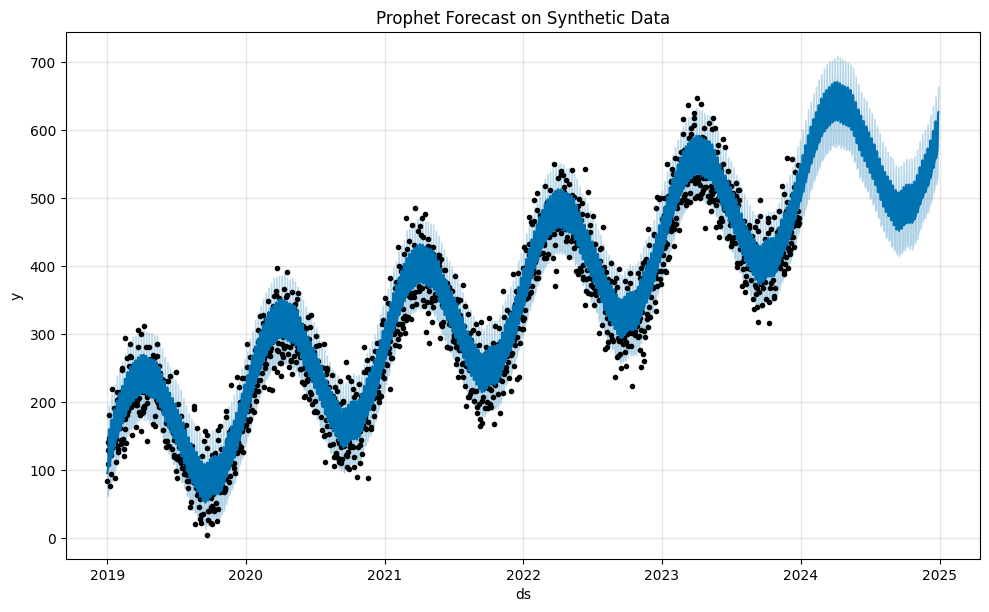

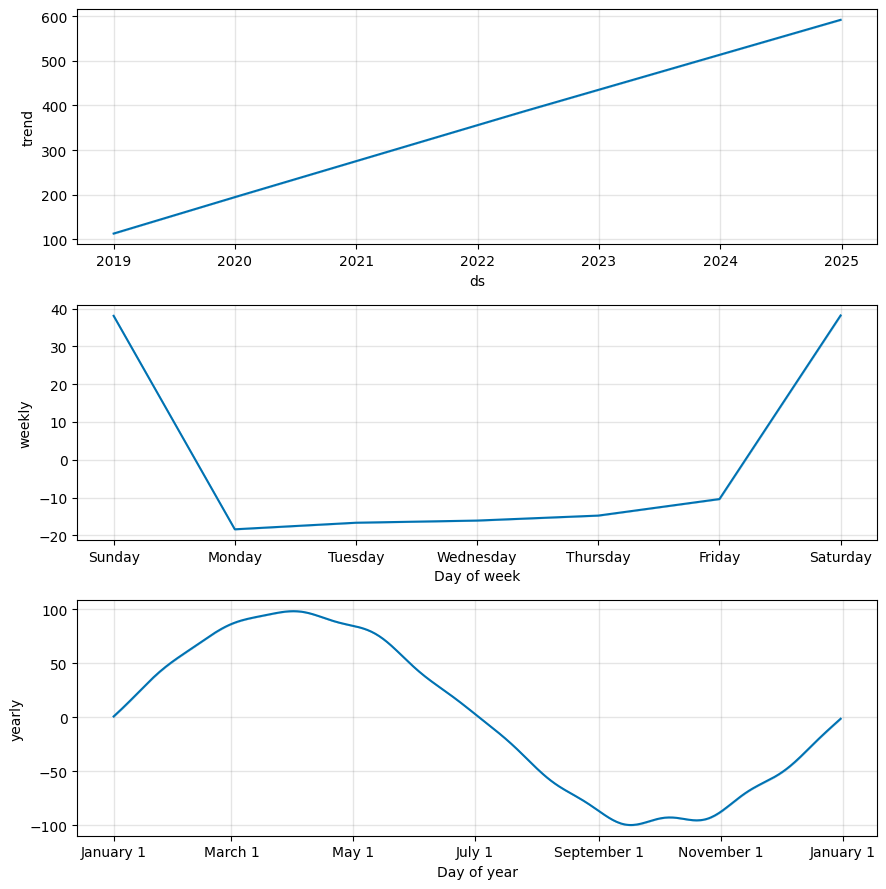

In [4]:
from prophet import Prophet


# Generar fechas diarias durante 5 años
dates = pd.date_range(start='2019-01-01', periods=5*365, freq='D')

# Generar ventas con tendencia, estacionalidad anual, semanal y ruido
# Tendencia lineal
trend = np.linspace(100, 500, len(dates))
# Estacionalidad anual (seno con período de 365 días)
annual_seasonality = 100 * np.sin(2 * np.pi * dates.dayofyear / 365.25)
# Estacionalidad semanal (picos los fines de semana)
weekly_seasonality = np.zeros(len(dates))
weekly_seasonality[dates.dayofweek >= 5] = 50 # Sábado (5) y Domingo (6)
# Ruido aleatorio
noise = np.random.normal(0, 30, len(dates))

# Combinar componentes para obtener las ventas sintéticas
synthetic_sales = trend + annual_seasonality + weekly_seasonality + noise

# Crear el DataFrame en el formato requerido por Prophet (ds, y)
synthetic_df = pd.DataFrame({'ds': dates, 'y': synthetic_sales})

print("Dataset sintético creado:")
print(synthetic_df.head())
print(synthetic_df.tail())


model_prophet = Prophet()

model_prophet.fit(synthetic_df)

# Crear un dataframe para el pronóstico futuro
# Pronosticar 1 año (365 días) hacia el futuro
future = model_prophet.make_future_dataframe(periods=365)

# Realizar el pronóstico
forecast = model_prophet.predict(future)

print("\nPronóstico de Prophet:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

# Graficar el pronóstico
fig1 = model_prophet.plot(forecast)
plt.title('Prophet Forecast on Synthetic Data')
plt.show()

# Graficar los componentes del pronóstico
fig2 = model_prophet.plot_components(forecast)
plt.show()

# Opcional: Comparar con los datos originales (si quieres graficar el train y test juntos)
# Puedes dividir synthetic_df en train/test si quieres evaluar las métricas como antes.
# For simplicity here, we are fitting on all synthetic data and forecasting.
